# matplotlib에서 fig, ax를 써야 하는 이유

## 방식 1 — plt 직접 호출 (암묵적 방식)

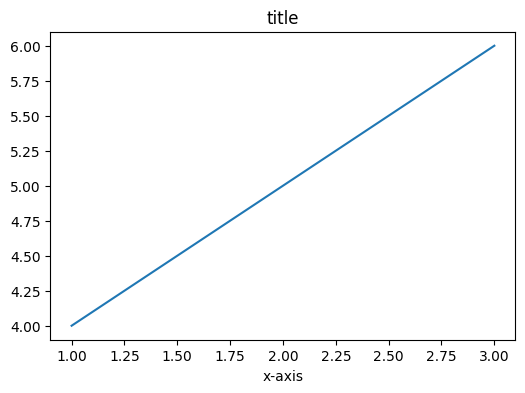

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("title")
plt.xlabel("x-axis")
plt.show()

## 방식 2 — fig, ax 명시적 방식

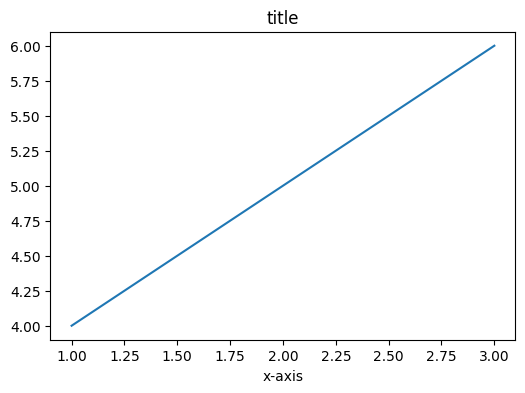

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("title")
ax.set_xlabel("x-axis")
plt.show()

## 아래와 같은 코드는 fig, ax 명시적 방식으로만 가능

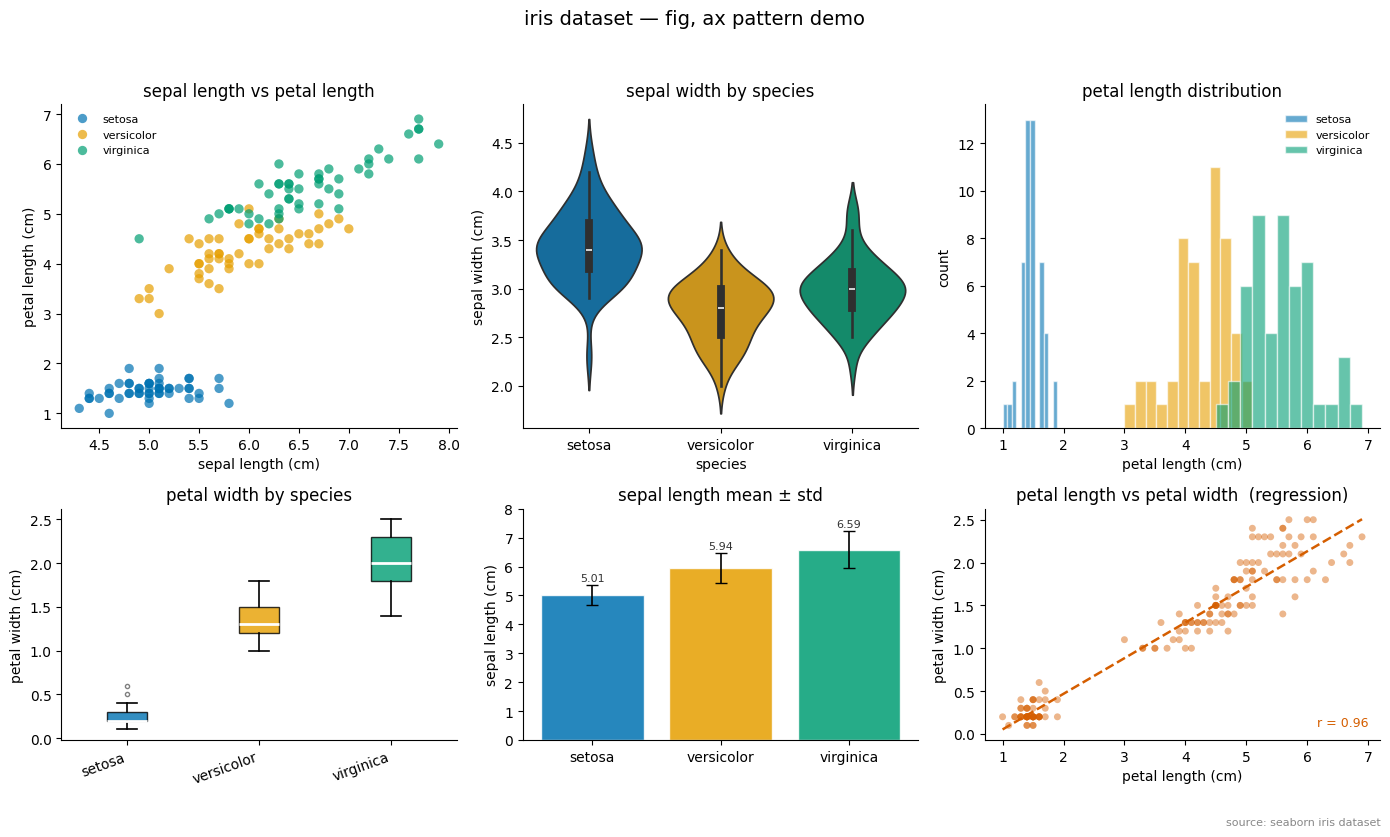

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

iris = sns.load_dataset("iris")

species_colors = {
    "setosa":     "#0072B2",
    "versicolor": "#E69F00",
    "virginica":  "#009E73"
}

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    dpi=100,
    gridspec_kw={"height_ratios": [1.4, 1]}
)

fig.suptitle("iris dataset — fig, ax pattern demo", fontsize=14, y=1.01)
fig.text(0.99, -0.01, "source: seaborn iris dataset",
         ha="right", fontsize=8, color="#888888")

# ── [0, 0]  scatter
sns.scatterplot(
    data=iris,
    x="sepal_length", y="petal_length",
    hue="species", palette=species_colors,
    alpha=0.7, s=45, edgecolor="none",
    ax=axes[0, 0]
)
axes[0, 0].set_title("sepal length vs petal length")
axes[0, 0].set_xlabel("sepal length (cm)")
axes[0, 0].set_ylabel("petal length (cm)")
axes[0, 0].legend(frameon=False, fontsize=8)
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

# ── [0, 1]  violin  hue= + legend=False
sns.violinplot(
    data=iris,
    x="species", y="sepal_width",
    hue="species",
    palette=species_colors,
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title("sepal width by species")
axes[0, 1].set_xlabel("species")
axes[0, 1].set_ylabel("sepal width (cm)")
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

# ── [0, 2]  histogram
for sp, c in species_colors.items():
    data = iris[iris["species"] == sp]["petal_length"]
    axes[0, 2].hist(data, bins=12, color=c, alpha=0.6,
                    edgecolor="white", label=sp)
axes[0, 2].set_title("petal length distribution")
axes[0, 2].set_xlabel("petal length (cm)")
axes[0, 2].set_ylabel("count")
axes[0, 2].legend(frameon=False, fontsize=8)
axes[0, 2].spines["top"].set_visible(False)
axes[0, 2].spines["right"].set_visible(False)

# ── [1, 0]  boxplot  tick_labels=
data_by_sp = [iris[iris["species"] == sp]["petal_width"].values
              for sp in species_colors]
bp = axes[1, 0].boxplot(
    data_by_sp,
    tick_labels=list(species_colors.keys()),
    patch_artist=True,
    medianprops=dict(color="white", lw=2),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.5)
)
for patch, c in zip(bp["boxes"], species_colors.values()):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[1, 0].set_xticklabels(list(species_colors.keys()), rotation=20, ha="right")
axes[1, 0].set_title("petal width by species")
axes[1, 0].set_ylabel("petal width (cm)")
axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)

# ── [1, 1]  bar
feat  = "sepal_length"
means = iris.groupby("species")[feat].mean()
stds  = iris.groupby("species")[feat].std()
x_pos = np.arange(len(means))

axes[1, 1].bar(x_pos, means.values,
               color=list(species_colors.values()),
               alpha=0.85, edgecolor="white",
               yerr=stds.values, capsize=4,
               error_kw=dict(lw=1.2, color="#555555"))
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(means.index)
axes[1, 1].set_title("sepal length mean ± std")
axes[1, 1].set_ylabel("sepal length (cm)")
axes[1, 1].set_ylim(0, 8)
for i, (m, s) in enumerate(zip(means.values, stds.values)):
    axes[1, 1].text(i, m + s + 0.15, f"{m:.2f}",
                    ha="center", fontsize=8, color="#333333")
axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)

# ── [1, 2]  regression
def plot_regression(ax, x_col, y_col, color):
    x = iris[x_col].values
    y = iris[y_col].values
    slope, intercept, r, *_ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.scatter(x, y, color=color, alpha=0.45, s=25, edgecolors="none")
    ax.plot(xline, slope * xline + intercept,
            color=color, lw=1.8, ls="--")
    ax.text(0.97, 0.06, f"r = {r:.2f}",
            transform=ax.transAxes,
            ha="right", fontsize=9, color=color)

plot_regression(axes[1, 2], "petal_length", "petal_width", "#D55E00")
axes[1, 2].set_title("petal length vs petal width  (regression)")
axes[1, 2].set_xlabel("petal length (cm)")
axes[1, 2].set_ylabel("petal width (cm)")
axes[1, 2].spines["top"].set_visible(False)
axes[1, 2].spines["right"].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

## `plt.xxx()` 직접 호출을 쓰면 안 되는 이유

---

- **전역 상태 의존** — `plt`는 내부적으로 "현재 활성화된 Figure/Axes"를 전역 변수로 관리합니다. 코드 어느 곳에서든 함수 호출 하나가 활성 axes를 조용히 바꿔버릴 수 있고, 이때 아무런 오류나 경고도 발생하지 않습니다.

- **반복문·함수 안에서 오작동** — `for` 루프나 헬퍼 함수 내부에서 `plt.subplot()` 또는 `plt.gca()`를 호출하면 의도한 axes가 아닌 "그 순간 활성화된" axes를 반환합니다. 버그가 코드 오류가 아닌 그림 결과로만 나타나 원인을 찾기 매우 어렵습니다.

- **재사용 불가** — `plt.plot()`을 내부에서 호출하는 플로팅 함수는 특정 axes를 인자로 받을 수 없습니다. 항상 전역 상태가 가리키는 곳에 그려지므로 함수로 만들어도 재사용이 불가능합니다.

- **subplot 독립 제어 불가** — 여러 subplot 중 하나에만 특정 옵션(눈금 회전, y축 범위, 로그 스케일 등)을 적용하려면 매번 `plt.subplot(n, m, i)`로 해당 subplot을 다시 활성화해야 합니다. axes 객체가 없으면 `axes[i]`처럼 직접 접근할 방법이 없습니다.

- **Figure 수준 옵션 접근 불가** — `fig.suptitle()`, `fig.text()`, `fig.tight_layout(rect=...)` 등 Figure 전체를 제어하는 메서드는 `fig` 객체 없이는 호출할 수 없습니다. `plt.suptitle()`처럼 래핑된 함수가 일부 있지만 세부 옵션(위치, 여백 등)을 조정하기 어렵습니다.

- **seaborn과 충돌** — seaborn의 모든 플로팅 함수는 `ax=` 인자로 대상 axes를 받습니다. `ax=`를 지정하지 않으면 seaborn이 새 Figure를 만들거나 의도치 않은 axes에 그려, 기존 subplot 레이아웃이 망가집니다.

- **디버깅 난이도 증가** — 전역 상태 기반이므로 실행 순서에 따라 결과가 달라집니다. 셀 실행 순서가 다른 Jupyter 환경에서는 같은 코드도 매번 다른 결과를 낼 수 있습니다.

---

### 참고 자료

- [Matplotlib 공식 — Axes API vs pyplot API 비교](https://matplotlib.org/stable/api/index.html)
- [Matplotlib 공식 — Figure and Axes 개요](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)
- [Matplotlib 공식 — subplot 튜토리얼](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)
- [Real Python — Matplotlib Guide (OO style 권장 이유)](https://realpython.com/python-matplotlib-guide/#the-pyplot-interface)
- [Stackoverflow — "What is the difference between plt and ax in matplotlib"](https://stackoverflow.com/questions/37970424/what-is-the-difference-between-drawing-plots-using-plot-axes-or-figure-in-matpl)